 ## AMAZON ECOMMERCE DATASET ANALYSIS

 ###  Data Cleaning & Preparation using Python (Pandas)


#### 1. PROBLEM STATEMENT

To find out the pattern ,trends and in which circumstances customers returned the products by analysing the 

ecommerce data set 

#### 2. Dataset collection

It contains amazon e commerce dataset from kaggle 

#### 3. Data loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv ("amazon_ecommerce_1M.csv.xls")
df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


#### 4.Data Understanding

In [2]:
df.shape

(1000000, 20)

In [3]:
df.describe()

,price,discount,final_price,rating,review_count,stock,seller_rating,shipping_time_days
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,13224.119093,28.996161,9938.876985,3.927226,32.626704,250.023345,3.750030,3.166389
std,18079.626921,14.681077,14271.885557,0.519443,43.382201,144.567038,0.722092,1.674178
min,200.030000,5.000000,101.460000,1.500000,0.000000,0.000000,2.500000,1.000000
25%,2700.147500,16.910000,1705.930000,3.600000,10.000000,125.000000,3.100000,2.000000
50%,4971.830000,28.070000,3790.795000,3.900000,20.000000,250.000000,3.800000,3.000000
75%,14134.482500,39.240000,10384.440000,4.300000,39.000000,375.000000,4.400000,5.000000
max,79999.700000,70.000000,75831.110000,5.000000,3408.000000,500.000000,5.000000,6.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1000000 non-null  object 
 1   product_id          1000000 non-null  object 
 2   category            1000000 non-null  object 
 3   subcategory         1000000 non-null  object 
 4   brand               1000000 non-null  object 
 5   price               1000000 non-null  float64
 6   discount            1000000 non-null  float64
 7   final_price         1000000 non-null  float64
 8   rating              1000000 non-null  float64
 9   review_count        1000000 non-null  int64  
 10  stock               1000000 non-null  int64  
 11  seller_id           1000000 non-null  object 
 12  seller_rating       1000000 non-null  float64
 13  purchase_date       1000000 non-null  object 
 14  shipping_time_days  1000000 non-null  int64  
 15  location        

#### 5. Data Cleaning 

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

#### 6. Exploratory data Analysis

In [7]:
df["location"].value_counts()

location
Delhi        200649
Bangalore    200270
Chennai      199902
Mumbai       199874
Hyderabad    199305
Name: count, dtype: int64

In [8]:
df["is_returned"].value_counts()

is_returned
False    884010
True     115990
Name: count, dtype: int64

In [9]:
df["delivery_status"].value_counts()

delivery_status
Delivered     295234
Delayed       294983
In Transit    293793
Returned      115990
Name: count, dtype: int64

In [10]:
df["payment_method"].value_counts()

payment_method
Cash on Delivery    250388
Credit Card         250324
UPI                 249951
Debit Card          249337
Name: count, dtype: int64

In [11]:
df["device"].value_counts()

device
Mobile App    333637
Web           333297
Tablet        333066
Name: count, dtype: int64

In [12]:
df["rating"].value_counts()

rating
3.9    76085
4.0    74253
3.8    73536
4.1    70828
3.7    69282
4.2    64950
3.6    62998
4.3    57378
3.5    55499
4.4    49801
3.4    46680
4.5    40985
3.3    37514
4.6    33011
5.0    30219
3.2    29118
4.7    25664
3.1    22188
4.8    19481
3.0    15888
4.9    14517
2.9    11171
2.8     7412
2.7     4870
2.6     2930
2.5     1669
2.4      979
2.3      555
2.2      296
2.1      121
2.0       71
1.9       29
1.7        8
1.8        8
1.6        5
1.5        1
Name: count, dtype: int64

#### 7. Data Filtering 

In [19]:
df.groupby("subcategory")["is_returned"].sum()

subcategory
Camera        5729
Cycling       7769
Decor         7916
Fitness       7742
Furniture     7708
Haircare      7711
Headphones    5507
Kids          7847
Kitchen       7651
Laptop        5638
Makeup        7855
Men           7875
Mobile        5677
Outdoor       7768
Skincare      7867
Women         7730
Name: is_returned, dtype: int64

In [20]:
df.groupby("location")["is_returned"].sum()

location
Bangalore    24433
Chennai      24429
Delhi        21272
Hyderabad    24380
Mumbai       21476
Name: is_returned, dtype: int64

In [21]:
df.groupby("brand")["is_returned"].sum()

brand
Adidas     9700
Apple      9687
Boat       9567
H&M        9526
HP         9528
LG         9686
Lenovo     9684
Nike       9824
Puma       9738
Samsung    9621
Sony       9784
Zara       9645
Name: is_returned, dtype: int64

#### 8. Data Visualisation

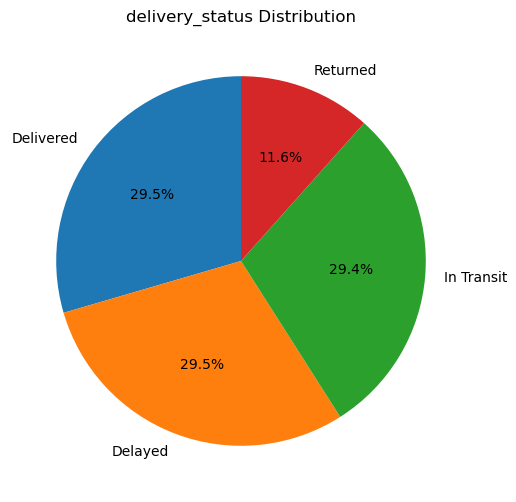

In [22]:
counts = df["delivery_status"].value_counts()

counts.plot.pie(autopct='%1.1f%%',startangle=90, figsize=(6,6),ylabel='') 

plt.title("delivery_status Distribution")
plt.show()

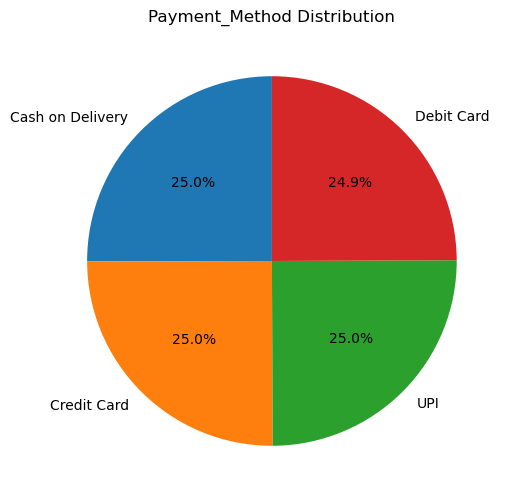

In [24]:
counts = df["payment_method"].value_counts()

counts.plot.pie(autopct='%1.1f%%',startangle=90, figsize=(6,6),ylabel='') 

plt.title("Payment_Method Distribution")
plt.show()

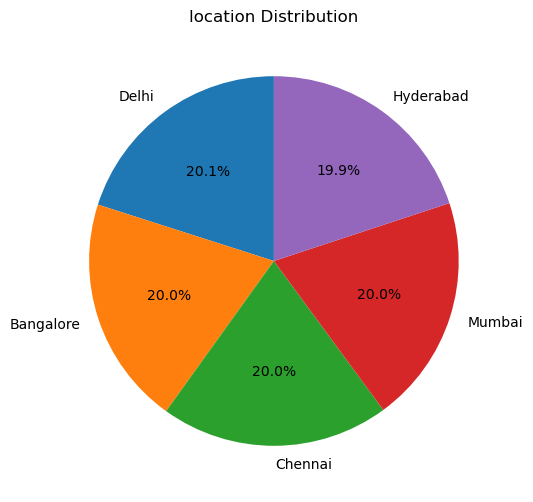

In [25]:
counts = df["location"].value_counts()

counts.plot.pie(autopct='%1.1f%%',startangle=90, figsize=(6,6),ylabel='') 

plt.title("location Distribution")
plt.show()

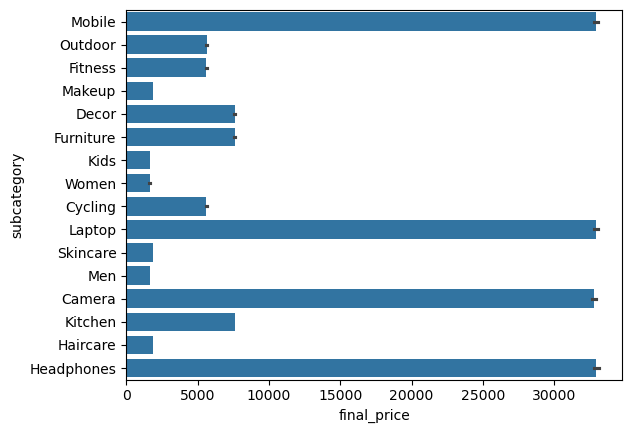

In [27]:
sns.barplot(x = "final_price", y = "subcategory", data= df)

plt.show()

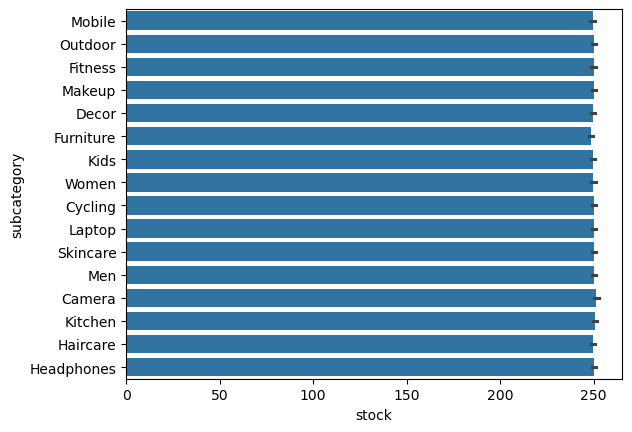

In [28]:
sns.barplot(x = "stock", y = "subcategory", data= df)

plt.show()

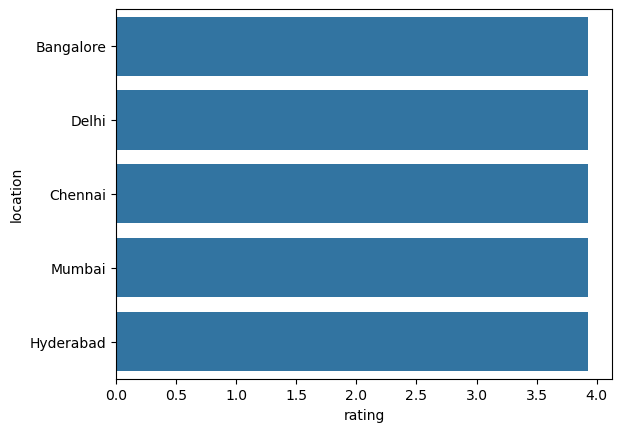

In [32]:
sns.barplot(x="rating", y="location", data=df)

plt.show()

#### 9. Business Insights 

In this dataset , Delivery status of the products showing below:

  Delivered products - 29.5%
  Delayed - 29.5 %
  In transit- 29.4%
  Is returned - 11.6 %

Among all the given  locations such as Bangalore, Delhi,Hyderabad ,chennai and Mumbai .

   returned status are Comparetively high in Mumbai location (21476) and low in Delhi location (21272)

Highest Returned brand is  NIKE ( 9824) and lowest returned brand is H&M (9526)

Highest Returned Product (subcategory vice ) is decor (7916) and lowest returned product is headphones(5507)

Minimum discount  is 5% and Maximum discount is 70 %

Minimum rating is 1.5 and Maximum rating 5 